In [1]:
from pathlib import Path
import sys
import torch

# ===============================
# 1. Locate project root
# ===============================
PROJECT_ROOT = Path.cwd().resolve().parent

# ===============================
# 2. Add module paths
# ===============================
sys.path.append(str(PROJECT_ROOT / "src" / "05_build_pytorch_dataset"))
sys.path.append(str(PROJECT_ROOT / "src" / "06_train_baseline_mlp"))

from vad_dataset import VADStackedFrameDataset
from baseline_mlp import BaselineMLP

# ===============================
# 3. Build dataset
# ===============================
train_dataset = VADStackedFrameDataset(
    generated_dir=str(PROJECT_ROOT / "data" / "generated" / "train"),
    split="train",
    manifest_type="noisy"
)

# ===============================
# 4. Build model
# ===============================
model = BaselineMLP(input_dim=1331, hidden_dim=256)
print(model)

# ===============================
# 5. Test one sample
# ===============================
x0, y0 = train_dataset[0]
print("\nSingle sample:")
print("x0 shape:", x0.shape)
print("y0:", y0.item())

# Add batch dimension
x0_batch = x0.unsqueeze(0)   # shape [1, 1331]
logit0 = model(x0_batch)

print("\nModel output for one sample:")
print("logit0 shape:", logit0.shape)
print("logit0:", logit0)

# ===============================
# 6. Test a mini-batch
# ===============================
x_batch = torch.stack([train_dataset[i][0] for i in range(4)], dim=0)
y_batch = torch.tensor([train_dataset[i][1].item() for i in range(4)], dtype=torch.float32)

print("\nMini-batch:")
print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)

logits = model(x_batch)

print("logits shape:", logits.shape)
print("logits:", logits)

[train] Loaded 3000 examples
[train] Total frames: 6726129
BaselineMLP(
  (net): Sequential(
    (0): Linear(in_features=1331, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
)

Single sample:
x0 shape: torch.Size([1331])
y0: 1.0

Model output for one sample:
logit0 shape: torch.Size([1])
logit0: tensor([0.1209], grad_fn=<SqueezeBackward1>)

Mini-batch:
x_batch shape: torch.Size([4, 1331])
y_batch shape: torch.Size([4])
logits shape: torch.Size([4])
logits: tensor([0.1209, 0.0716, 0.2546, 0.0993], grad_fn=<SqueezeBackward1>)


/Users/hongjingren/Documents/6140/Noise-Robust-Voice-Activity-Detection-FINAL/src/05_build_pytorch_dataset/vad_dataset.py:149: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  return torch.from_numpy(x_frame), torch.tensor(y_frame, dtype=torch.float32)


### DataLoader and one training step check

In [1]:
from pathlib import Path
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# ===============================
# 1. Locate project root
# ===============================
PROJECT_ROOT = Path.cwd().resolve().parent

# ===============================
# 2. Add module paths
# ===============================
sys.path.append(str(PROJECT_ROOT / "src" / "05_build_pytorch_dataset"))
sys.path.append(str(PROJECT_ROOT / "src" / "06_train_baseline_mlp"))

from vad_dataset import VADStackedFrameDataset
from baseline_mlp import BaselineMLP

# ===============================
# 3. Build dataset and dataloader
# ===============================
train_dataset = VADStackedFrameDataset(
    generated_dir=str(PROJECT_ROOT / "data" / "generated" / "train"),
    split="train",
    manifest_type="noisy"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=0
)

# ===============================
# 4. Build model, loss, optimizer
# ===============================
model = BaselineMLP(input_dim=1331, hidden_dim=256)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)
print("\nLoss function:", criterion)
print("Optimizer:", optimizer)

# ===============================
# 5. Get one batch
# ===============================
x_batch, y_batch = next(iter(train_loader))

print("\nOne batch from DataLoader:")
print("x_batch shape:", x_batch.shape)
print("x_batch dtype:", x_batch.dtype)
print("y_batch shape:", y_batch.shape)
print("y_batch dtype:", y_batch.dtype)
print("Unique labels in batch:", torch.unique(y_batch))

# ===============================
# 6. Forward pass
# ===============================
logits_before = model(x_batch)

print("\nForward pass:")
print("logits_before shape:", logits_before.shape)

loss_before = criterion(logits_before, y_batch)
print("loss_before:", loss_before.item())

# ===============================
# 7. Backward + optimizer step
# ===============================
optimizer.zero_grad()
loss_before.backward()

# Check one gradient tensor
for name, param in model.named_parameters():
    if param.grad is not None:
        print(f"\nGradient check: {name}")
        print("grad shape:", param.grad.shape)
        print("grad norm:", param.grad.norm().item())
        break

optimizer.step()

# ===============================
# 8. Forward pass again after update
# ===============================
logits_after = model(x_batch)
loss_after = criterion(logits_after, y_batch)

print("\nAfter one optimizer step:")
print("logits_after shape:", logits_after.shape)
print("loss_after:", loss_after.item())

# ===============================
# 9. Check whether parameters changed
# ===============================
print("\nParameter update check:")
for name, param in model.named_parameters():
    print(name, "mean =", param.data.mean().item())

[train] Loaded 3000 examples
[train] Total frames: 6726129
BaselineMLP(
  (net): Sequential(
    (0): Linear(in_features=1331, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


/Users/hongjingren/Documents/6140/Noise-Robust-Voice-Activity-Detection-FINAL/src/05_build_pytorch_dataset/vad_dataset.py:149: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  return torch.from_numpy(x_frame), torch.tensor(y_frame, dtype=torch.float32)



One batch from DataLoader:
x_batch shape: torch.Size([512, 1331])
x_batch dtype: torch.float32
y_batch shape: torch.Size([512])
y_batch dtype: torch.float32
Unique labels in batch: tensor([0., 1.])

Forward pass:
logits_before shape: torch.Size([512])
loss_before: 0.6802000999450684

Gradient check: net.0.weight
grad shape: torch.Size([256, 1331])
grad norm: 0.9493545889854431

After one optimizer step:
logits_after shape: torch.Size([512])
loss_after: 0.5827546119689941

Parameter update check:
net.0.weight mean = 6.14962846157141e-05
net.0.bias mean = -0.0009206962422467768
net.2.weight mean = 0.0015636703465133905
net.2.bias mean = 0.003635925706475973


### Metrics sanity check

In [2]:
from pathlib import Path
import sys
import torch

PROJECT_ROOT = Path.cwd().resolve().parent

sys.path.append(str(PROJECT_ROOT / "src" / "06_train_baseline_mlp"))

from metrics import (
    logits_to_probs,
    probs_to_preds,
    compute_confusion_counts,
    compute_f1,
    compute_far,
    compute_miss_rate,
    compute_metrics_from_logits,
)

# ==========================================
# 1. Simple hand-crafted example
# ==========================================
y_true = torch.tensor([1, 1, 0, 0, 1, 0], dtype=torch.float32)
logits = torch.tensor([2.0, -1.0, 1.5, -2.0, 0.3, -0.7], dtype=torch.float32)

probs = logits_to_probs(logits)
preds = probs_to_preds(probs, threshold=0.5)

print("y_true:", y_true)
print("logits:", logits)
print("probs:", probs)
print("preds:", preds)

tp, tn, fp, fn = compute_confusion_counts(y_true, preds)
print("\nConfusion counts")
print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)

print("\nMetrics from counts")
print("F1:", compute_f1(tp, fp, fn))
print("FAR:", compute_far(fp, tn))
print("Miss Rate:", compute_miss_rate(fn, tp))

# ==========================================
# 2. Direct metrics from logits
# ==========================================
metrics = compute_metrics_from_logits(logits, y_true, threshold=0.5)

print("\nMetrics from logits")
for k, v in metrics.items():
    print(f"{k}: {v}")

y_true: tensor([1., 1., 0., 0., 1., 0.])
logits: tensor([ 2.0000, -1.0000,  1.5000, -2.0000,  0.3000, -0.7000])
probs: tensor([0.8808, 0.2689, 0.8176, 0.1192, 0.5744, 0.3318])
preds: tensor([1, 0, 1, 0, 1, 0])

Confusion counts
TP: 2
TN: 2
FP: 1
FN: 1

Metrics from counts
F1: 0.6666666666666666
FAR: 0.3333333333333333
Miss Rate: 0.3333333333333333

Metrics from logits
f1: 0.6666666666666666
far: 0.3333333333333333
miss_rate: 0.3333333333333333
tp: 2
tn: 2
fp: 1
fn: 1


### One full train epoch and dev evaluation

In [3]:
from pathlib import Path
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# ===============================
# 1. Locate project root
# ===============================
PROJECT_ROOT = Path.cwd().resolve().parent

# ===============================
# 2. Add module paths
# ===============================
sys.path.append(str(PROJECT_ROOT / "src" / "05_build_pytorch_dataset"))
sys.path.append(str(PROJECT_ROOT / "src" / "06_train_baseline_mlp"))

from vad_dataset import VADStackedFrameDataset
from baseline_mlp import BaselineMLP
from train_utils import train_one_epoch, evaluate

# ===============================
# 3. Device
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===============================
# 4. Build datasets
# ===============================
train_dataset = VADStackedFrameDataset(
    generated_dir=str(PROJECT_ROOT / "data" / "generated" / "train"),
    split="train",
    manifest_type="noisy"
)

dev_dataset = VADStackedFrameDataset(
    generated_dir=str(PROJECT_ROOT / "data" / "generated" / "dev"),
    split="dev",
    manifest_type="noisy"
)

# ===============================
# 5. Build dataloaders
# ===============================
train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=0
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=0
)

# ===============================
# 6. Build model, loss, optimizer
# ===============================
model = BaselineMLP(input_dim=1331, hidden_dim=256).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ===============================
# 7. Run one training epoch
# ===============================
train_metrics = train_one_epoch(
    model=model,
    dataloader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
)

print("\nTrain metrics after 1 epoch:")
for k, v in train_metrics.items():
    print(f"{k}: {v:.6f}")

# ===============================
# 8. Evaluate on dev
# ===============================
dev_metrics = evaluate(
    model=model,
    dataloader=dev_loader,
    criterion=criterion,
    device=device,
)

print("\nDev metrics after 1 epoch:")
for k, v in dev_metrics.items():
    print(f"{k}: {v:.6f}")

Using device: cpu
[train] Loaded 3000 examples
[train] Total frames: 6726129
[dev] Loaded 500 examples
[dev] Total frames: 1088453

Train metrics after 1 epoch:
loss: 0.358369
f1: 0.880479
far: 0.328307
miss_rate: 0.104796

Dev metrics after 1 epoch:
loss: 0.372436
f1: 0.872350
far: 0.341527
miss_rate: 0.108737


### Threshold tuning on dev set

In [4]:
import torch

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

model.eval()

results = []

with torch.no_grad():
    all_logits = []
    all_labels = []

    for x_batch, y_batch in dev_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)

        all_logits.append(logits.cpu())
        all_labels.append(y_batch.cpu())

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)

print("Total dev samples:", all_logits.shape[0])

from metrics import compute_metrics_from_logits

for th in thresholds:
    metrics = compute_metrics_from_logits(all_logits, all_labels, threshold=th)

    print(f"\nThreshold = {th}")
    print(f"F1: {metrics['f1']:.6f}")
    print(f"FAR: {metrics['far']:.6f}")
    print(f"Miss Rate: {metrics['miss_rate']:.6f}")

Total dev samples: 1088453

Threshold = 0.3
F1: 0.862672
FAR: 0.615554
Miss Rate: 0.033558

Threshold = 0.4
F1: 0.870300
FAR: 0.474565
Miss Rate: 0.066801

Threshold = 0.5
F1: 0.872350
FAR: 0.341527
Miss Rate: 0.108737

Threshold = 0.6
F1: 0.865251
FAR: 0.233637
Miss Rate: 0.158157

Threshold = 0.7
F1: 0.847854
FAR: 0.152201
Miss Rate: 0.214229


We performed threshold tuning on the development set to determine the optimal decision boundary for converting predicted probabilities into binary speech/non-speech labels.

We evaluated thresholds in the range [0.3, 0.7]. As the threshold decreases, the model becomes more aggressive in predicting speech, resulting in lower miss rate but significantly higher false alarm rate. Conversely, increasing the threshold makes the model more conservative, reducing false alarms but increasing missed speech frames.

The best performance was achieved at threshold = 0.5, with an F1 score of 0.872. This indicates that the model is well-calibrated, and the default threshold of 0.5 provides the best balance between false alarms and missed detections.

Therefore, we use threshold = 0.5 for all subsequent evaluations.

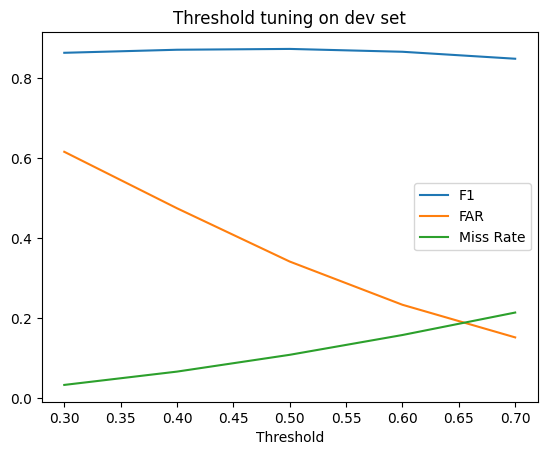

In [5]:
import matplotlib.pyplot as plt

f1_list = []
far_list = []
miss_list = []

for th in thresholds:
    metrics = compute_metrics_from_logits(all_logits, all_labels, threshold=th)
    f1_list.append(metrics["f1"])
    far_list.append(metrics["far"])
    miss_list.append(metrics["miss_rate"])

plt.figure()
plt.plot(thresholds, f1_list, label="F1")
plt.plot(thresholds, far_list, label="FAR")
plt.plot(thresholds, miss_list, label="Miss Rate")
plt.xlabel("Threshold")
plt.legend()
plt.title("Threshold tuning on dev set")
plt.show()

###  Final baseline training + logging

#### **Experiment 1 — Baseline MLP (5 Epochs)**

**Configuration**
- Model: MLP (2-layer)
- Input dimension: 1331 (stacked features)
- Hidden dimension: 256
- Batch size: 512
- Learning rate: 1e-3
- Optimizer: Adam
- Loss: BCEWithLogitsLoss
- Threshold: 0.5
- Epochs: 5
- Device: CPU


In [6]:
# Multi-epoch baseline training
from pathlib import Path
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
# ==========================================
# Experiment 1: Baseline MLP (5 epochs)
# Configuration:
#   hidden_dim = 256
#   batch_size = 512
#   learning_rate = 1e-3
#   threshold = 0.5
#   epochs = 5
#
# Training time:
#   ~137 minutes (CPU)
#
# Purpose:
#   Establish a stable and reproducible baseline
# ==========================================
# ===============================
# 1. Locate project root
# ===============================
PROJECT_ROOT = Path.cwd().resolve().parent

# ===============================
# 2. Add module paths
# ===============================
sys.path.append(str(PROJECT_ROOT / "src" / "05_build_pytorch_dataset"))
sys.path.append(str(PROJECT_ROOT / "src" / "06_train_baseline_mlp"))

from vad_dataset import VADStackedFrameDataset
from baseline_mlp import BaselineMLP
from train_utils import train_one_epoch, evaluate

# ===============================
# 3. Reproducibility
# ===============================
torch.manual_seed(42)

# ===============================
# 4. Device
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===============================
# 5. Build datasets
# ===============================
train_dataset = VADStackedFrameDataset(
    generated_dir=str(PROJECT_ROOT / "data" / "generated" / "train"),
    split="train",
    manifest_type="noisy"
)

dev_dataset = VADStackedFrameDataset(
    generated_dir=str(PROJECT_ROOT / "data" / "generated" / "dev"),
    split="dev",
    manifest_type="noisy"
)

# ===============================
# 6. Build dataloaders
# ===============================
train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=0
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=0
)

# ===============================
# 7. Build model, loss, optimizer
# ===============================
model = BaselineMLP(input_dim=1331, hidden_dim=256).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ===============================
# 8. Training config
# ===============================
num_epochs = 5
best_dev_f1 = -1.0
best_epoch = -1
best_state_dict = None

history = {
    "train_loss": [],
    "train_f1": [],
    "train_far": [],
    "train_miss_rate": [],
    "dev_loss": [],
    "dev_f1": [],
    "dev_far": [],
    "dev_miss_rate": [],
}

# ===============================
# 9. Multi-epoch training loop
# ===============================
for epoch in range(1, num_epochs + 1):
    print(f"\n===== Epoch {epoch}/{num_epochs} =====")

    train_metrics = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    dev_metrics = evaluate(
        model=model,
        dataloader=dev_loader,
        criterion=criterion,
        device=device,
    )

    history["train_loss"].append(train_metrics["loss"])
    history["train_f1"].append(train_metrics["f1"])
    history["train_far"].append(train_metrics["far"])
    history["train_miss_rate"].append(train_metrics["miss_rate"])

    history["dev_loss"].append(dev_metrics["loss"])
    history["dev_f1"].append(dev_metrics["f1"])
    history["dev_far"].append(dev_metrics["far"])
    history["dev_miss_rate"].append(dev_metrics["miss_rate"])

    print("Train:")
    for k, v in train_metrics.items():
        print(f"  {k}: {v:.6f}")

    print("Dev:")
    for k, v in dev_metrics.items():
        print(f"  {k}: {v:.6f}")

    # Save best model based on dev F1
    if dev_metrics["f1"] > best_dev_f1:
        best_dev_f1 = dev_metrics["f1"]
        best_epoch = epoch
        best_state_dict = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        print(f"  [Best model updated] epoch={epoch}, dev_f1={best_dev_f1:.6f}")

print("\n===== Training finished =====")
print(f"Best epoch: {best_epoch}")
print(f"Best dev F1: {best_dev_f1:.6f}")

Using device: cpu
[train] Loaded 3000 examples
[train] Total frames: 6726129
[dev] Loaded 500 examples
[dev] Total frames: 1088453

===== Epoch 1/5 =====
Train:
  loss: 0.358226
  f1: 0.880414
  far: 0.328247
  miss_rate: 0.104934
Dev:
  loss: 0.374551
  f1: 0.870642
  far: 0.322274
  miss_rate: 0.118437
  [Best model updated] epoch=1, dev_f1=0.870642

===== Epoch 2/5 =====
Train:
  loss: 0.340067
  f1: 0.886811
  far: 0.298272
  miss_rate: 0.103305
Dev:
  loss: 0.370267
  f1: 0.871183
  far: 0.311934
  miss_rate: 0.121021
  [Best model updated] epoch=2, dev_f1=0.871183

===== Epoch 3/5 =====
Train:
  loss: 0.331811
  f1: 0.889711
  far: 0.283942
  miss_rate: 0.102857
Dev:
  loss: 0.359193
  f1: 0.875677
  far: 0.281004
  miss_rate: 0.123684
  [Best model updated] epoch=3, dev_f1=0.875677

===== Epoch 4/5 =====
Train:
  loss: 0.326471
  f1: 0.891635
  far: 0.274734
  miss_rate: 0.102476
Dev:
  loss: 0.362616
  f1: 0.874682
  far: 0.292687
  miss_rate: 0.121409

===== Epoch 5/5 =====
Tr

In [7]:
for key, values in history.items():
    print(key, values)

train_loss [0.35822644282684557, 0.340067181869133, 0.33181085080019024, 0.3264710712204344, 0.3224446508588165]
train_f1 [0.8804139340621202, 0.88681091719394, 0.889711284620896, 0.8916349450756113, 0.8930967646996111]
train_far [0.32824691761903163, 0.29827232126505443, 0.2839418149633145, 0.27473418493834234, 0.26895451678632587]
train_miss_rate [0.10493400953453841, 0.10330463619253986, 0.10285736137861211, 0.10247621647340395, 0.10178111296002543]
dev_loss [0.3745512402691406, 0.3702665067876711, 0.35919250875639347, 0.36261598298628867, 0.3544213227794951]
dev_f1 [0.8706420815191732, 0.8711827778677121, 0.8756767300404446, 0.8746819805152957, 0.8774849452762524]
dev_far [0.3222742032148703, 0.311933663109497, 0.28100447553365, 0.29268678122363057, 0.2898690734959553]
dev_miss_rate [0.11843723193205448, 0.12102130733500294, 0.12368372829230594, 0.12140905143452038, 0.11737359143988506]


train/dev loss curve

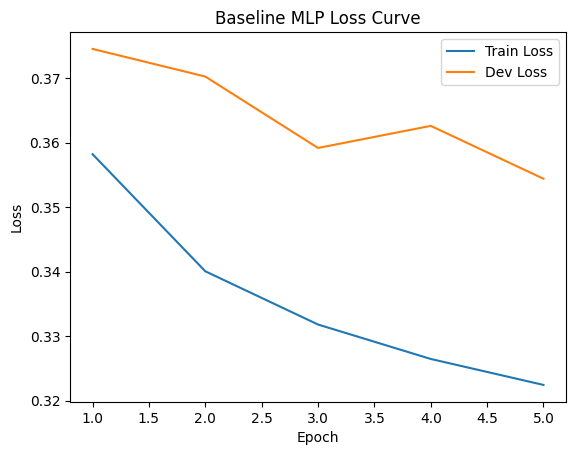

In [8]:
import matplotlib.pyplot as plt

epochs = list(range(1, num_epochs + 1))

plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["dev_loss"], label="Dev Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline MLP Loss Curve")
plt.legend()
plt.show()

dev F1 curve

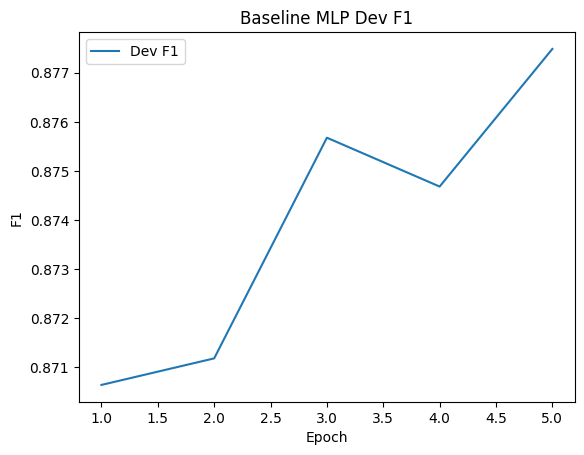

In [9]:
plt.figure()
plt.plot(epochs, history["dev_f1"], label="Dev F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Baseline MLP Dev F1")
plt.legend()
plt.show()

Final test evaluation

In [10]:
from pathlib import Path
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# ===============================
# 1. Locate project root
# ===============================
PROJECT_ROOT = Path.cwd().resolve().parent

# ===============================
# 2. Add module paths
# ===============================
sys.path.append(str(PROJECT_ROOT / "src" / "05_build_pytorch_dataset"))
sys.path.append(str(PROJECT_ROOT / "src" / "06_train_baseline_mlp"))

from vad_dataset import VADStackedFrameDataset
from baseline_mlp import BaselineMLP
from train_utils import evaluate

# ===============================
# 3. Device
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===============================
# 4. Build test dataset and dataloader
# ===============================
test_dataset = VADStackedFrameDataset(
    generated_dir=str(PROJECT_ROOT / "data" / "generated" / "test"),
    split="test",
    manifest_type="noisy"
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=0
)

# ===============================
# 5. Rebuild model and load best checkpoint
# ===============================
best_model = BaselineMLP(input_dim=1331, hidden_dim=256).to(device)
best_model.load_state_dict(best_state_dict)

criterion = nn.BCEWithLogitsLoss()

# ===============================
# 6. Evaluate on test
# ===============================
test_metrics = evaluate(
    model=best_model,
    dataloader=test_loader,
    criterion=criterion,
    device=device,
)

print("\nFinal test metrics (best checkpoint):")
for k, v in test_metrics.items():
    print(f"{k}: {v:.6f}")

Using device: cpu
[test] Loaded 500 examples
[test] Total frames: 1086683

Final test metrics (best checkpoint):
loss: 0.338991
f1: 0.886458
far: 0.285996
miss_rate: 0.102305


Summary:

**Training Time**
- Total training time: ~132 minutes

**Best Validation Performance**
- Best epoch: 5
- Dev F1: 0.8775
- Dev FAR: 0.2899
- Dev Miss Rate: 0.1174

**Test Performance (using best checkpoint)**
- Test F1: 0.8865
- Test FAR: 0.2860
- Test Miss Rate: 0.1023

**Observations**
- Training and validation loss decrease steadily, indicating stable optimization.
- No significant overfitting observed (small gap between train and dev).
- Dev F1 continues improving up to epoch 5, suggesting the model has not fully converged.
- The model achieves a good balance between false alarm rate and miss rate.

#### Experiment 2 — Extended Training (More Epochs)

**Goal**
To investigate whether the model continues improving beyond 5 epochs and to check if performance saturates or overfitting occurs.

**Configuration**
- Same as Experiment 1
- Epochs: 8 (or 10)

**Motivation**
- Dev F1 in Experiment 1 was still increasing at epoch 5
- Suggests model has not yet converged
- Increasing training epochs may further improve performance

**Expected Outcomes**
- Dev F1 may improve slightly
- Eventually performance will plateau
- Potential overfitting if epochs are too large

**Note**
We keep all other hyperparameters fixed to isolate the effect of training duration.

In [12]:
from pathlib import Path
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# ==========================================
# Experiment 2: Extended Training (8 epochs)
# Same configuration as Experiment 1:
#   hidden_dim = 256
#   batch_size = 512
#   learning_rate = 1e-3
#   threshold = 0.5
#
# Purpose:
#   Check whether performance continues improving
#   when training for more epochs.
# ==========================================

# ===============================
# 1. Locate project root
# ===============================
PROJECT_ROOT = Path.cwd().resolve().parent

# ===============================
# 2. Add module paths
# ===============================
sys.path.append(str(PROJECT_ROOT / "src" / "05_build_pytorch_dataset"))
sys.path.append(str(PROJECT_ROOT / "src" / "06_train_baseline_mlp"))

from vad_dataset import VADStackedFrameDataset
from baseline_mlp import BaselineMLP
from train_utils import train_one_epoch, evaluate

# ===============================
# 3. Reproducibility
# ===============================
torch.manual_seed(42)

# ===============================
# 4. Device
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===============================
# 5. Build datasets
# ===============================
train_dataset = VADStackedFrameDataset(
    generated_dir=str(PROJECT_ROOT / "data" / "generated" / "train"),
    split="train",
    manifest_type="noisy"
)

dev_dataset = VADStackedFrameDataset(
    generated_dir=str(PROJECT_ROOT / "data" / "generated" / "dev"),
    split="dev",
    manifest_type="noisy"
)

# ===============================
# 6. Build dataloaders
# ===============================
train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=0
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=0
)

# ===============================
# 7. Build model, loss, optimizer
# ===============================
model_exp2 = BaselineMLP(input_dim=1331, hidden_dim=256).to(device)
criterion_exp2 = nn.BCEWithLogitsLoss()
optimizer_exp2 = torch.optim.Adam(model_exp2.parameters(), lr=1e-3)

# ===============================
# 8. Training config
# ===============================
num_epochs_exp2 = 8
best_dev_f1_exp2 = -1.0
best_epoch_exp2 = -1
best_state_dict_exp2 = None

history_exp2 = {
    "train_loss": [],
    "train_f1": [],
    "train_far": [],
    "train_miss_rate": [],
    "dev_loss": [],
    "dev_f1": [],
    "dev_far": [],
    "dev_miss_rate": [],
}

# ===============================
# 9. Multi-epoch training loop
# ===============================
for epoch in range(1, num_epochs_exp2 + 1):
    print(f"\n===== Experiment 2 | Epoch {epoch}/{num_epochs_exp2} =====")

    train_metrics_exp2 = train_one_epoch(
        model=model_exp2,
        dataloader=train_loader,
        criterion=criterion_exp2,
        optimizer=optimizer_exp2,
        device=device,
    )

    dev_metrics_exp2 = evaluate(
        model=model_exp2,
        dataloader=dev_loader,
        criterion=criterion_exp2,
        device=device,
    )

    history_exp2["train_loss"].append(train_metrics_exp2["loss"])
    history_exp2["train_f1"].append(train_metrics_exp2["f1"])
    history_exp2["train_far"].append(train_metrics_exp2["far"])
    history_exp2["train_miss_rate"].append(train_metrics_exp2["miss_rate"])

    history_exp2["dev_loss"].append(dev_metrics_exp2["loss"])
    history_exp2["dev_f1"].append(dev_metrics_exp2["f1"])
    history_exp2["dev_far"].append(dev_metrics_exp2["far"])
    history_exp2["dev_miss_rate"].append(dev_metrics_exp2["miss_rate"])

    print("Train:")
    for k, v in train_metrics_exp2.items():
        print(f"  {k}: {v:.6f}")

    print("Dev:")
    for k, v in dev_metrics_exp2.items():
        print(f"  {k}: {v:.6f}")

    if dev_metrics_exp2["f1"] > best_dev_f1_exp2:
        best_dev_f1_exp2 = dev_metrics_exp2["f1"]
        best_epoch_exp2 = epoch
        best_state_dict_exp2 = {
            k: v.detach().cpu().clone()
            for k, v in model_exp2.state_dict().items()
        }
        print(f"  [Best model updated] epoch={epoch}, dev_f1={best_dev_f1_exp2:.6f}")

print("\n===== Experiment 2 finished =====")
print(f"Best epoch (exp2): {best_epoch_exp2}")
print(f"Best dev F1 (exp2): {best_dev_f1_exp2:.6f}")

Using device: cpu
[train] Loaded 3000 examples
[train] Total frames: 6726129
[dev] Loaded 500 examples
[dev] Total frames: 1088453

===== Experiment 2 | Epoch 1/8 =====
Train:
  loss: 0.358226
  f1: 0.880414
  far: 0.328247
  miss_rate: 0.104934
Dev:
  loss: 0.374551
  f1: 0.870642
  far: 0.322274
  miss_rate: 0.118437
  [Best model updated] epoch=1, dev_f1=0.870642

===== Experiment 2 | Epoch 2/8 =====
Train:
  loss: 0.340067
  f1: 0.886811
  far: 0.298272
  miss_rate: 0.103305
Dev:
  loss: 0.370267
  f1: 0.871183
  far: 0.311934
  miss_rate: 0.121021
  [Best model updated] epoch=2, dev_f1=0.871183

===== Experiment 2 | Epoch 3/8 =====
Train:
  loss: 0.331811
  f1: 0.889711
  far: 0.283942
  miss_rate: 0.102857
Dev:
  loss: 0.359193
  f1: 0.875677
  far: 0.281004
  miss_rate: 0.123684
  [Best model updated] epoch=3, dev_f1=0.875677

===== Experiment 2 | Epoch 4/8 =====
Train:
  loss: 0.326471
  f1: 0.891635
  far: 0.274734
  miss_rate: 0.102476
Dev:
  loss: 0.362616
  f1: 0.874682
  f

#### Experiment 2 — Training Curves

Train / Dev Loss Curve

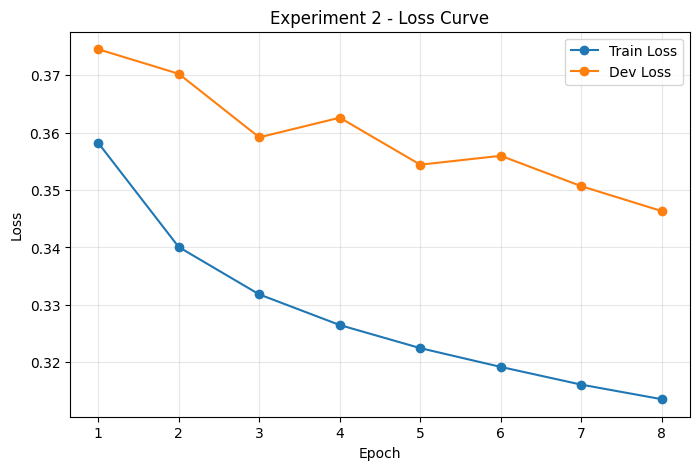

In [14]:
import matplotlib.pyplot as plt

epochs_exp2 = list(range(1, num_epochs_exp2 + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs_exp2, history_exp2["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_exp2, history_exp2["dev_loss"], marker="o", label="Dev Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 2 - Loss Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Dev F1 Curve

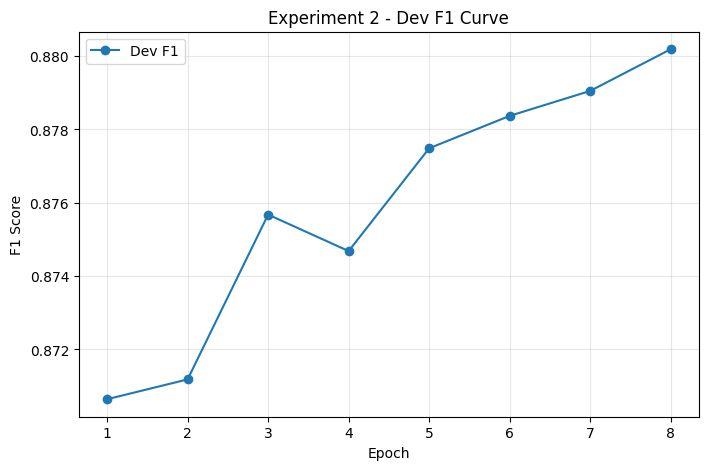

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_exp2, history_exp2["dev_f1"], marker="o", label="Dev F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Experiment 2 - Dev F1 Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Dev FAR Curve

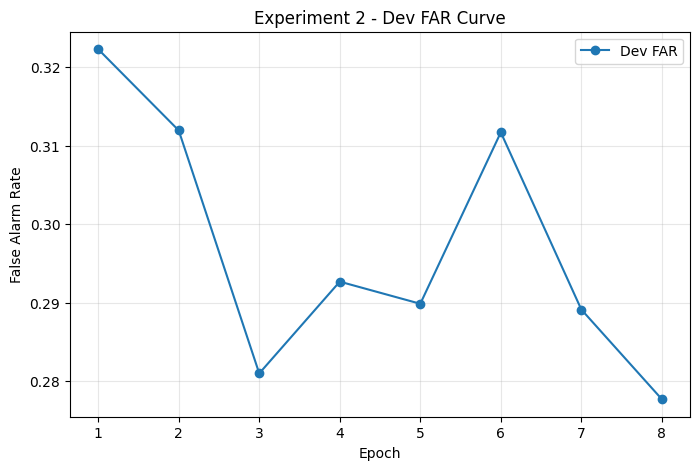

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_exp2, history_exp2["dev_far"], marker="o", label="Dev FAR")
plt.xlabel("Epoch")
plt.ylabel("False Alarm Rate")
plt.title("Experiment 2 - Dev FAR Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Dev Miss Rate Curve

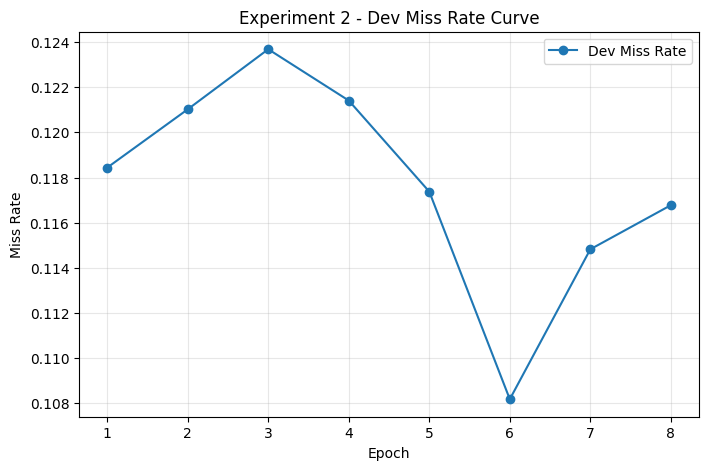

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_exp2, history_exp2["dev_miss_rate"], marker="o", label="Dev Miss Rate")
plt.xlabel("Epoch")
plt.ylabel("Miss Rate")
plt.title("Experiment 2 - Dev Miss Rate Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Summary of Experiment 2**

In this experiment, we kept the same baseline configuration as Experiment 1 and increased the training duration from 5 epochs to 8 epochs.

**Configuration**
- Hidden dimension: 256
- Batch size: 512
- Learning rate: 1e-3
- Threshold: 0.5
- Epochs: 8

**Best Validation Result**
- Best epoch: 8
- Best dev F1: 0.8802

The plots below show the training dynamics across epochs, including the loss trend and validation performance.

#### Experiment 3 — Continued Training (Epoch 9–10)

Instead of retraining the model from scratch, we continue training from the best checkpoint obtained in Experiment 2 (epoch 8).

**Motivation**
- Reduce training
- Efficiently explore further improvement
- Avoid redundant computation

**Configuration**
- Initial weights: best checkpoint from Experiment 2
- Hidden dimension: 256
- Batch size: 512
- Learning rate: 1e-3
- Additional epochs: 2

This approach significantly reduces runtime while preserving training progress.

In [18]:
from pathlib import Path
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# ==========================================
# Experiment 3: Continue training from the
# best checkpoint of Experiment 2
# ==========================================

# ===============================
# 1. Locate project root
# ===============================
PROJECT_ROOT = Path.cwd().resolve().parent

# ===============================
# 2. Add module paths
# ===============================
sys.path.append(str(PROJECT_ROOT / "src" / "05_build_pytorch_dataset"))
sys.path.append(str(PROJECT_ROOT / "src" / "06_train_baseline_mlp"))

from vad_dataset import VADStackedFrameDataset
from baseline_mlp import BaselineMLP
from train_utils import train_one_epoch, evaluate

# ===============================
# 3. Reproducibility
# ===============================
torch.manual_seed(42)

# ===============================
# 4. Device
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===============================
# 5. Build datasets
# ===============================
train_dataset = VADStackedFrameDataset(
    generated_dir=str(PROJECT_ROOT / "data" / "generated" / "train"),
    split="train",
    manifest_type="noisy"
)

dev_dataset = VADStackedFrameDataset(
    generated_dir=str(PROJECT_ROOT / "data" / "generated" / "dev"),
    split="dev",
    manifest_type="noisy"
)

# ===============================
# 6. Build dataloaders
# ===============================
train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# ===============================
# 7. Rebuild model from best exp2 checkpoint
# ===============================
model_exp3 = BaselineMLP(input_dim=1331, hidden_dim=256).to(device)
model_exp3.load_state_dict(best_state_dict_exp2)

criterion_exp3 = nn.BCEWithLogitsLoss()
optimizer_exp3 = torch.optim.Adam(model_exp3.parameters(), lr=1e-3)

# ===============================
# 8. Continue-training config
# ===============================
num_epochs_exp3 = 2   # this corresponds to epoch 9 and 10
start_epoch_exp3 = best_epoch_exp2

best_dev_f1_exp3 = best_dev_f1_exp2
best_epoch_exp3 = best_epoch_exp2
best_state_dict_exp3 = {
    k: v.detach().cpu().clone()
    for k, v in best_state_dict_exp2.items()
}

history_exp3 = {
    "train_loss": [],
    "train_f1": [],
    "train_far": [],
    "train_miss_rate": [],
    "dev_loss": [],
    "dev_f1": [],
    "dev_far": [],
    "dev_miss_rate": [],
    "epoch_number": [],
}

# ===============================
# 9. Continue training loop
# ===============================
for local_epoch in range(1, num_epochs_exp3 + 1):
    global_epoch = start_epoch_exp3 + local_epoch

    print(f"\n===== Experiment 3 | Continued Epoch {global_epoch} =====")

    train_metrics_exp3 = train_one_epoch(
        model=model_exp3,
        dataloader=train_loader,
        criterion=criterion_exp3,
        optimizer=optimizer_exp3,
        device=device,
    )

    dev_metrics_exp3 = evaluate(
        model=model_exp3,
        dataloader=dev_loader,
        criterion=criterion_exp3,
        device=device,
    )

    history_exp3["epoch_number"].append(global_epoch)
    history_exp3["train_loss"].append(train_metrics_exp3["loss"])
    history_exp3["train_f1"].append(train_metrics_exp3["f1"])
    history_exp3["train_far"].append(train_metrics_exp3["far"])
    history_exp3["train_miss_rate"].append(train_metrics_exp3["miss_rate"])

    history_exp3["dev_loss"].append(dev_metrics_exp3["loss"])
    history_exp3["dev_f1"].append(dev_metrics_exp3["f1"])
    history_exp3["dev_far"].append(dev_metrics_exp3["far"])
    history_exp3["dev_miss_rate"].append(dev_metrics_exp3["miss_rate"])

    print("Train:")
    for k, v in train_metrics_exp3.items():
        print(f"  {k}: {v:.6f}")

    print("Dev:")
    for k, v in dev_metrics_exp3.items():
        print(f"  {k}: {v:.6f}")

    if dev_metrics_exp3["f1"] > best_dev_f1_exp3:
        best_dev_f1_exp3 = dev_metrics_exp3["f1"]
        best_epoch_exp3 = global_epoch
        best_state_dict_exp3 = {
            k: v.detach().cpu().clone()
            for k, v in model_exp3.state_dict().items()
        }
        print(f"  [Best model updated] epoch={global_epoch}, dev_f1={best_dev_f1_exp3:.6f}")

print("\n===== Experiment 3 finished =====")
print(f"Best epoch after continuation: {best_epoch_exp3}")
print(f"Best dev F1 after continuation: {best_dev_f1_exp3:.6f}")

Using device: cpu
[train] Loaded 3000 examples
[train] Total frames: 6726129
[dev] Loaded 500 examples
[dev] Total frames: 1088453

===== Experiment 3 | Continued Epoch 9 =====


/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Train:
  loss: 0.311547
  f1: 0.897046
  far: 0.253128
  miss_rate: 0.099998
Dev:
  loss: 0.346734
  f1: 0.880430
  far: 0.284258
  miss_rate: 0.114047
  [Best model updated] epoch=9, dev_f1=0.880430

===== Experiment 3 | Continued Epoch 10 =====
Train:
  loss: 0.309859
  f1: 0.897787
  far: 0.250604
  miss_rate: 0.099516
Dev:
  loss: 0.348696
  f1: 0.879552
  far: 0.275772
  miss_rate: 0.118591

===== Experiment 3 finished =====
Best epoch after continuation: 9
Best dev F1 after continuation: 0.880430


In [19]:
## continuation history
for key, values in history_exp3.items():
    print(key, values)

train_loss [0.3115471332105628, 0.30985894386083446]
train_f1 [0.8970463928879934, 0.8977868289502191]
train_far [0.25312829117204483, 0.2506044843481328]
train_miss_rate [0.09999814075655997, 0.09951579385046781]
dev_loss [0.34673383901815763, 0.3486958263693309]
dev_f1 [0.8804298770912565, 0.879551694528956]
dev_far [0.28425751165099783, 0.27577158975368166]
dev_miss_rate [0.11404722510669602, 0.11859126725926004]
epoch_number [9, 10]


**Experimrnt 3 Training Curves**

Loss curve

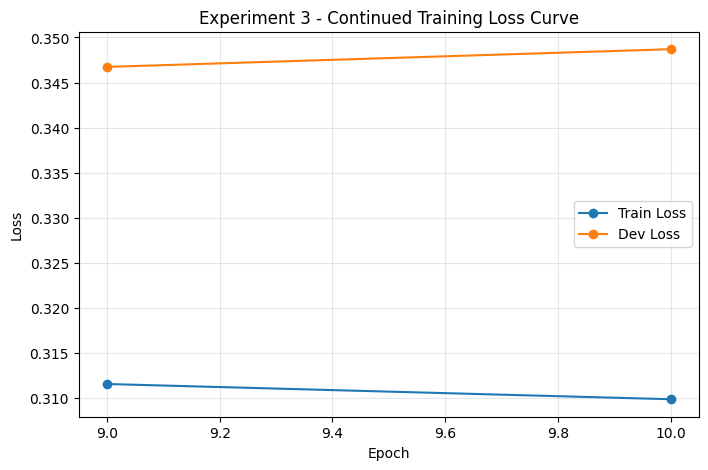

In [20]:
import matplotlib.pyplot as plt

epochs_exp3 = history_exp3["epoch_number"]

plt.figure(figsize=(8, 5))
plt.plot(epochs_exp3, history_exp3["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_exp3, history_exp3["dev_loss"], marker="o", label="Dev Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 3 - Continued Training Loss Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Dev F1 curve

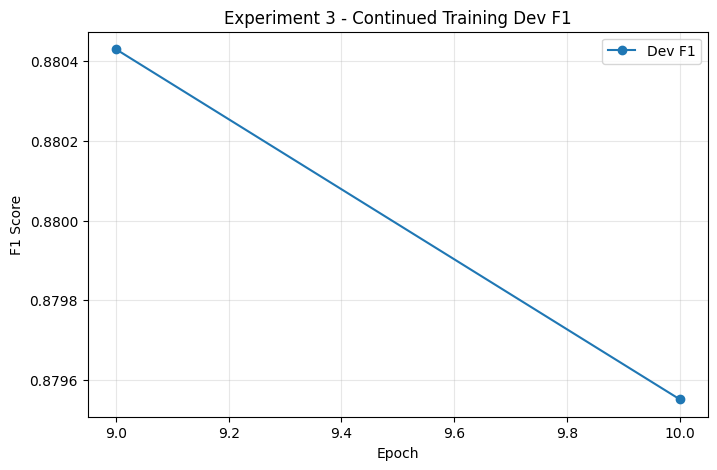

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_exp3, history_exp3["dev_f1"], marker="o", label="Dev F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Experiment 3 - Continued Training Dev F1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Dev FAR curve

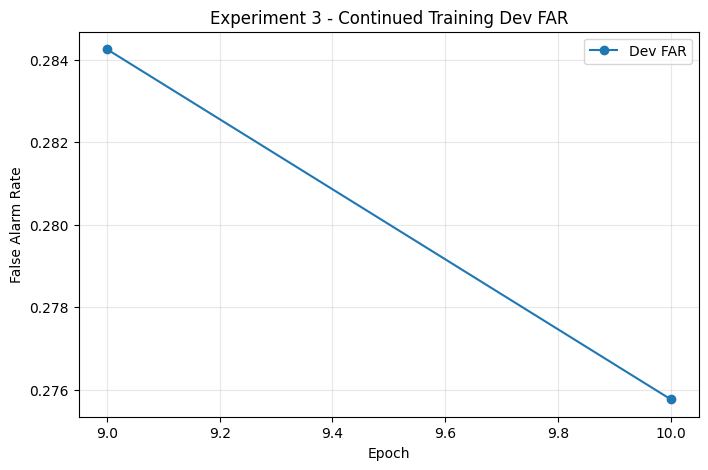

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_exp3, history_exp3["dev_far"], marker="o", label="Dev FAR")
plt.xlabel("Epoch")
plt.ylabel("False Alarm Rate")
plt.title("Experiment 3 - Continued Training Dev FAR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Dev Miss Rate curve

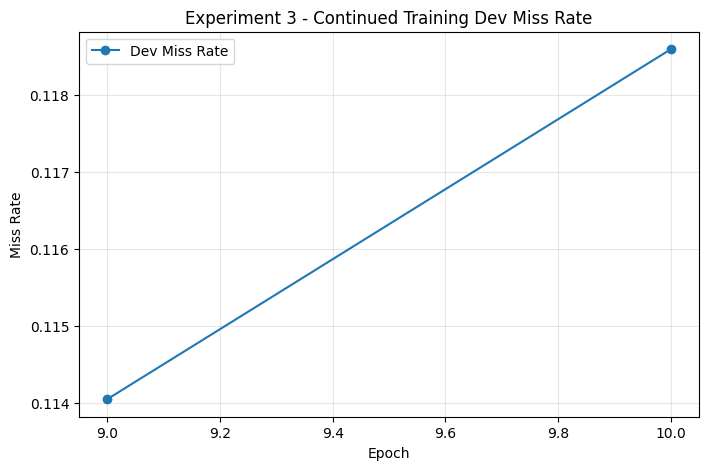

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_exp3, history_exp3["dev_miss_rate"], marker="o", label="Dev Miss Rate")
plt.xlabel("Epoch")
plt.ylabel("Miss Rate")
plt.title("Experiment 3 - Continued Training Dev Miss Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Continued Training Analysis (Epoch 9–10)

To efficiently explore further improvements, we continued training from the best checkpoint obtained in Experiment 2 (epoch 8) instead of retraining from scratch.

**Observations**
- At epoch 9, the validation F1 score reaches its highest value (0.8804), indicating a slight improvement over previous epochs.
- At epoch 10, the validation F1 score decreases slightly, suggesting that further training does not provide additional benefits.
- The validation loss remains nearly unchanged between epoch 9 and 10, indicating that the model has already reached a stable convergence point.
- The false alarm rate decreases slightly at epoch 10, but this is accompanied by an increase in miss rate, reflecting the typical trade-off between precision and recall.

**Conclusion**
The results confirm that the model has already converged by epoch 9. Continuing training beyond this point does not improve overall performance and may lead to slight degradation.

Therefore, the checkpoint at epoch 9 is selected as the final baseline model.

**Training Curves Epoch 1-10**

In [24]:
full_epochs = list(range(1, len(history_exp2["train_loss"]) + 1)) + history_exp3["epoch_number"]

full_train_loss = history_exp2["train_loss"] + history_exp3["train_loss"]
full_dev_loss = history_exp2["dev_loss"] + history_exp3["dev_loss"]
full_dev_f1 = history_exp2["dev_f1"] + history_exp3["dev_f1"]
full_dev_far = history_exp2["dev_far"] + history_exp3["dev_far"]
full_dev_miss = history_exp2["dev_miss_rate"] + history_exp3["dev_miss_rate"]

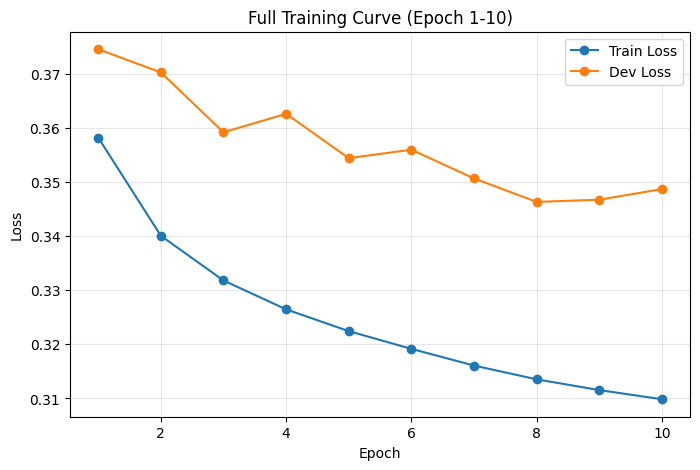

In [25]:
# full Loss curve
plt.figure(figsize=(8, 5))
plt.plot(full_epochs, full_train_loss, marker="o", label="Train Loss")
plt.plot(full_epochs, full_dev_loss, marker="o", label="Dev Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Full Training Curve (Epoch 1-10)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

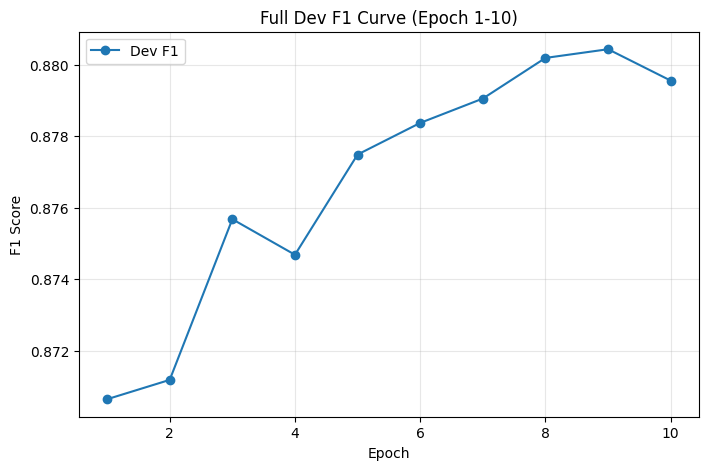

In [26]:
# Full Dev F1 curve
plt.figure(figsize=(8, 5))
plt.plot(full_epochs, full_dev_f1, marker="o", label="Dev F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Full Dev F1 Curve (Epoch 1-10)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

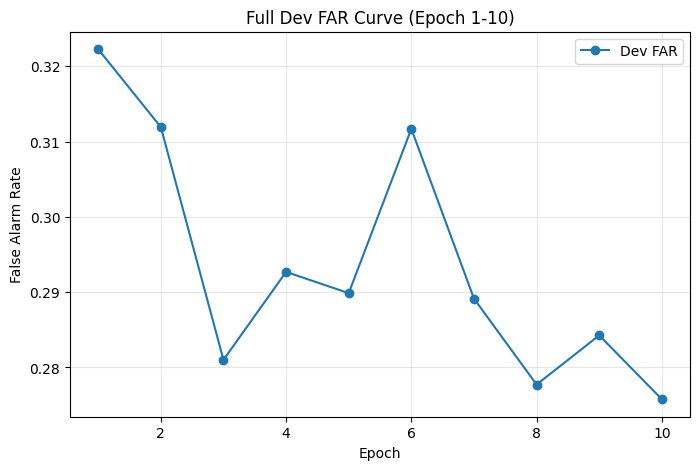

In [27]:
# Full dev FAR curve
plt.figure(figsize=(8, 5))
plt.plot(full_epochs, full_dev_far, marker="o", label="Dev FAR")
plt.xlabel("Epoch")
plt.ylabel("False Alarm Rate")
plt.title("Full Dev FAR Curve (Epoch 1-10)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

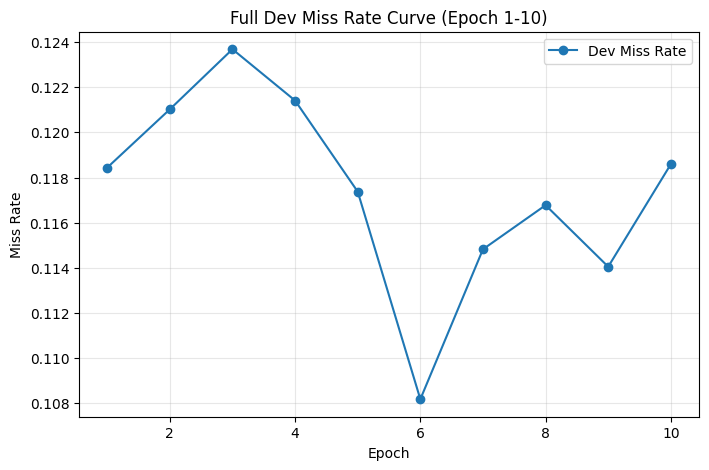

In [28]:
# Full dev Miss Rate curve
plt.figure(figsize=(8, 5))
plt.plot(full_epochs, full_dev_miss, marker="o", label="Dev Miss Rate")
plt.xlabel("Epoch")
plt.ylabel("Miss Rate")
plt.title("Full Dev Miss Rate Curve (Epoch 1-10)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Training Dynamics Analysis (Epoch 1–10)

We analyze the full training process from epoch 1 to epoch 10 to understand convergence behavior and generalization performance.

**Observations**
- The training loss decreases monotonically across all epochs, indicating stable optimization.
- The validation loss shows an overall downward trend with minor fluctuations, suggesting good generalization without significant overfitting.
- The validation F1 score improves steadily from epoch 1 to epoch 9, reaching its peak at epoch 9.
- After epoch 9, the validation F1 score slightly decreases, indicating that the model has reached its optimal performance and begins to saturate.
- The false alarm rate (FAR) generally decreases over epochs, while the miss rate remains within a stable range, showing a balanced trade-off between precision and recall.

**Conclusion**
The model demonstrates stable learning behavior and good generalization. The performance improves consistently up to epoch 9, after which additional training yields diminishing returns. This indicates that the model has effectively converged by epoch 9.

Therefore, epoch 9 is selected as the optimal stopping point for the baseline model.

#### Experiment 3 — Final Test Evaluation (Best Checkpoint)

**Final Model Selection**

Based on the validation experiments, the best model was obtained at **epoch 9**, with a development F1 score of **0.8804**. Since validation performance no longer improved after this point, we selected the epoch 9 checkpoint as the final baseline model.

We then evaluated this checkpoint on the held-out test set to obtain the final Stage 1 baseline performance.

In [29]:
from pathlib import Path
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# ===============================
# 1. Locate project root
# ===============================
PROJECT_ROOT = Path.cwd().resolve().parent

# ===============================
# 2. Add module paths
# ===============================
sys.path.append(str(PROJECT_ROOT / "src" / "05_build_pytorch_dataset"))
sys.path.append(str(PROJECT_ROOT / "src" / "06_train_baseline_mlp"))

from vad_dataset import VADStackedFrameDataset
from baseline_mlp import BaselineMLP
from train_utils import evaluate

# ===============================
# 3. Device
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===============================
# 4. Build test dataset and dataloader
# ===============================
test_dataset = VADStackedFrameDataset(
    generated_dir=str(PROJECT_ROOT / "data" / "generated" / "test"),
    split="test",
    manifest_type="noisy"
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=4,
    pin_memory=False
)

# ===============================
# 5. Rebuild model and load best checkpoint from Experiment 3
# ===============================
final_model = BaselineMLP(input_dim=1331, hidden_dim=256).to(device)
final_model.load_state_dict(best_state_dict_exp3)

criterion = nn.BCEWithLogitsLoss()

# ===============================
# 6. Evaluate on test
# ===============================
final_test_metrics = evaluate(
    model=final_model,
    dataloader=test_loader,
    criterion=criterion,
    device=device,
)

print("\nFinal test metrics (best checkpoint from Experiment 3):")
for k, v in final_test_metrics.items():
    print(f"{k}: {v:.6f}")

Using device: cpu
[test] Loaded 500 examples
[test] Total frames: 1086683

Final test metrics (best checkpoint from Experiment 3):
loss: 0.331321
f1: 0.889214
far: 0.281467
miss_rate: 0.098898


#### Experiment 4 — Learning Rate Comparison

In this experiment, we compare a small range of learning rates while keeping the rest of the baseline configuration fixed.

**Fixed configuration**
- Model: Baseline MLP
- Hidden dimension: 256
- Batch size: 512
- Optimizer: Adam
- Threshold: 0.5

**Compared learning rates**
- 1e-4
- 5e-4
- 1e-3

**Goal**
To evaluate how the learning rate affects convergence speed and validation performance, and to verify whether the baseline choice of 1e-3 is reasonable.

In [30]:
from pathlib import Path
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ===============================
# 1. Locate project root
# ===============================
PROJECT_ROOT = Path.cwd().resolve().parent

# ===============================
# 2. Add module paths
# ===============================
sys.path.append(str(PROJECT_ROOT / "src" / "05_build_pytorch_dataset"))
sys.path.append(str(PROJECT_ROOT / "src" / "06_train_baseline_mlp"))

from vad_dataset import VADStackedFrameDataset
from baseline_mlp import BaselineMLP
from train_utils import train_one_epoch, evaluate

# ===============================
# 3. Reproducibility
# ===============================
torch.manual_seed(42)

# ===============================
# 4. Device
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===============================
# 5. Build datasets
# ===============================
train_dataset = VADStackedFrameDataset(
    generated_dir=str(PROJECT_ROOT / "data" / "generated" / "train"),
    split="train",
    manifest_type="noisy"
)

dev_dataset = VADStackedFrameDataset(
    generated_dir=str(PROJECT_ROOT / "data" / "generated" / "dev"),
    split="dev",
    manifest_type="noisy"
)

# ===============================
# 6. Build dataloaders
# ===============================
train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=4,
    pin_memory=False
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=4,
    pin_memory=False
)

# ===============================
# 7. Learning rate candidates
# ===============================
lr_candidates = [1e-4, 5e-4, 1e-3]
num_epochs_lr = 3

lr_results = {}
lr_summary = []

# ===============================
# 8. Run comparison
# ===============================
for lr in lr_candidates:
    print("\n" + "=" * 70)
    print(f"Learning rate experiment: lr = {lr}")
    print("=" * 70)

    torch.manual_seed(42)

    model_lr = BaselineMLP(input_dim=1331, hidden_dim=256).to(device)
    criterion_lr = nn.BCEWithLogitsLoss()
    optimizer_lr = torch.optim.Adam(model_lr.parameters(), lr=lr)

    history_lr = {
        "train_loss": [],
        "train_f1": [],
        "dev_loss": [],
        "dev_f1": [],
        "dev_far": [],
        "dev_miss_rate": [],
    }

    best_dev_f1_lr = -1.0
    best_epoch_lr = -1

    for epoch in range(1, num_epochs_lr + 1):
        print(f"\n--- lr={lr} | epoch {epoch}/{num_epochs_lr} ---")

        train_metrics_lr = train_one_epoch(
            model=model_lr,
            dataloader=train_loader,
            criterion=criterion_lr,
            optimizer=optimizer_lr,
            device=device,
        )

        dev_metrics_lr = evaluate(
            model=model_lr,
            dataloader=dev_loader,
            criterion=criterion_lr,
            device=device,
        )

        history_lr["train_loss"].append(train_metrics_lr["loss"])
        history_lr["train_f1"].append(train_metrics_lr["f1"])
        history_lr["dev_loss"].append(dev_metrics_lr["loss"])
        history_lr["dev_f1"].append(dev_metrics_lr["f1"])
        history_lr["dev_far"].append(dev_metrics_lr["far"])
        history_lr["dev_miss_rate"].append(dev_metrics_lr["miss_rate"])

        print("Train:")
        for k, v in train_metrics_lr.items():
            print(f"  {k}: {v:.6f}")

        print("Dev:")
        for k, v in dev_metrics_lr.items():
            print(f"  {k}: {v:.6f}")

        if dev_metrics_lr["f1"] > best_dev_f1_lr:
            best_dev_f1_lr = dev_metrics_lr["f1"]
            best_epoch_lr = epoch

    lr_results[lr] = {
        "history": history_lr,
        "best_dev_f1": best_dev_f1_lr,
        "best_epoch": best_epoch_lr,
        "final_dev_loss": history_lr["dev_loss"][-1],
        "final_dev_far": history_lr["dev_far"][-1],
        "final_dev_miss_rate": history_lr["dev_miss_rate"][-1],
    }

    lr_summary.append({
        "lr": lr,
        "best_epoch": best_epoch_lr,
        "best_dev_f1": best_dev_f1_lr,
        "final_dev_loss": history_lr["dev_loss"][-1],
        "final_dev_far": history_lr["dev_far"][-1],
        "final_dev_miss_rate": history_lr["dev_miss_rate"][-1],
    })

print("\n===== Learning Rate Comparison Summary =====")
for row in lr_summary:
    print(row)

Using device: cpu
[train] Loaded 3000 examples
[train] Total frames: 6726129
[dev] Loaded 500 examples
[dev] Total frames: 1088453

Learning rate experiment: lr = 0.0001

--- lr=0.0001 | epoch 1/3 ---
Train:
  loss: 0.360542
  f1: 0.879745
  far: 0.341167
  miss_rate: 0.101876
Dev:
  loss: 0.373110
  f1: 0.870136
  far: 0.316013
  miss_rate: 0.121493

--- lr=0.0001 | epoch 2/3 ---
Train:
  loss: 0.338485
  f1: 0.887251
  far: 0.300756
  miss_rate: 0.101671
Dev:
  loss: 0.367580
  f1: 0.870751
  far: 0.283044
  miss_rate: 0.131713

--- lr=0.0001 | epoch 3/3 ---
Train:
  loss: 0.330456
  f1: 0.890264
  far: 0.287292
  miss_rate: 0.100722
Dev:
  loss: 0.363035
  f1: 0.874749
  far: 0.305454
  miss_rate: 0.116869

Learning rate experiment: lr = 0.0005

--- lr=0.0005 | epoch 1/3 ---
Train:
  loss: 0.356090
  f1: 0.881105
  far: 0.326783
  miss_rate: 0.104164
Dev:
  loss: 0.370729
  f1: 0.872716
  far: 0.335659
  miss_rate: 0.110097

--- lr=0.0005 | epoch 2/3 ---
Train:
  loss: 0.337001
  f1

Learning Rate Comparison

In [31]:
print("Learning Rate Comparison")
print("-" * 80)
print(f"{'LR':<10}{'Best Epoch':<12}{'Best Dev F1':<15}{'Final Dev Loss':<18}{'Final FAR':<12}{'Final Miss':<12}")

for row in lr_summary:
    print(
        f"{row['lr']:<10}"
        f"{row['best_epoch']:<12}"
        f"{row['best_dev_f1']:<15.6f}"
        f"{row['final_dev_loss']:<18.6f}"
        f"{row['final_dev_far']:<12.6f}"
        f"{row['final_dev_miss_rate']:<12.6f}"
    )

Learning Rate Comparison
--------------------------------------------------------------------------------
LR        Best Epoch  Best Dev F1    Final Dev Loss    Final FAR   Final Miss  
0.0001    3           0.874749       0.363035          0.305454    0.116869    
0.0005    3           0.877270       0.358569          0.311641    0.110182    
0.001     3           0.875677       0.359193          0.281004    0.123684    


dev F1 curve for different learning rate

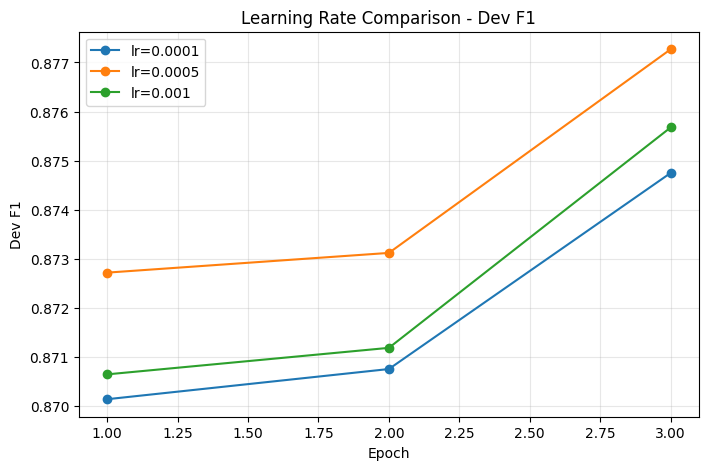

In [32]:
plt.figure(figsize=(8, 5))

for lr in lr_candidates:
    epochs = list(range(1, num_epochs_lr + 1))
    plt.plot(
        epochs,
        lr_results[lr]["history"]["dev_f1"],
        marker="o",
        label=f"lr={lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Dev F1")
plt.title("Learning Rate Comparison - Dev F1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

dev loss curve for different learning rate

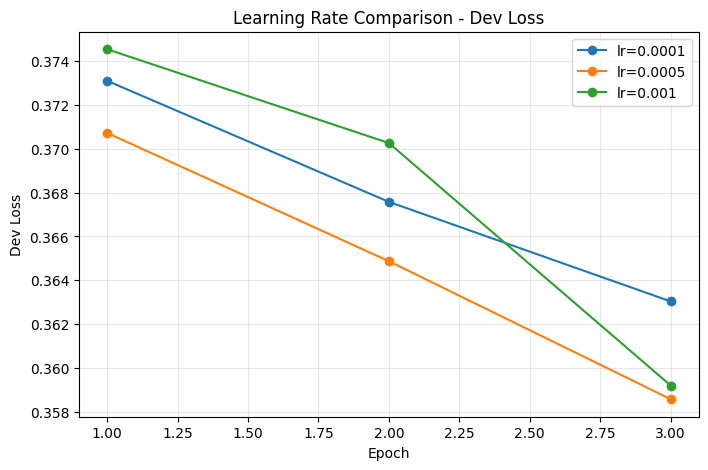

In [33]:
plt.figure(figsize=(8, 5))

for lr in lr_candidates:
    epochs = list(range(1, num_epochs_lr + 1))
    plt.plot(
        epochs,
        lr_results[lr]["history"]["dev_loss"],
        marker="o",
        label=f"lr={lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Dev Loss")
plt.title("Learning Rate Comparison - Dev Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

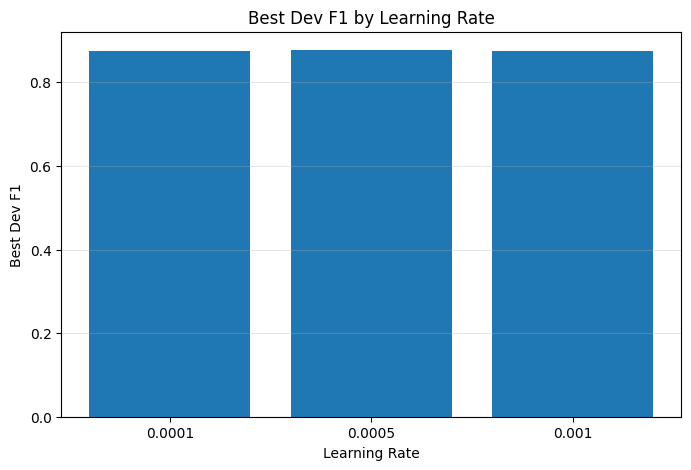

In [34]:
best_f1_values = [lr_results[lr]["best_dev_f1"] for lr in lr_candidates]

plt.figure(figsize=(8, 5))
plt.bar([str(lr) for lr in lr_candidates], best_f1_values)
plt.xlabel("Learning Rate")
plt.ylabel("Best Dev F1")
plt.title("Best Dev F1 by Learning Rate")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

#### Learning Rate Tuning

We evaluated three learning rates (1e-4, 5e-4, and 1e-3) while keeping all other hyperparameters fixed. Each configuration was trained for 3 epochs to compare convergence behavior and validation performance.

**Results**
- The learning rate of 5e-4 achieved the highest validation F1 score (0.8773) and the lowest validation loss.
- The learning rate of 1e-3 converged faster but showed slightly lower F1 and higher miss rate.
- The learning rate of 1e-4 converged more slowly and achieved the lowest performance among the three.

**Analysis**
- A smaller learning rate (1e-4) leads to slower convergence.
- A larger learning rate (1e-3) accelerates training but may introduce a trade-off between false alarms and missed detections.
- The intermediate value (5e-4) provides a better balance between convergence speed and generalization performance.

**Conclusion**
The learning rate of 5e-4 demonstrates the best performance in early training. However, since the baseline model trained with 1e-3 already achieves strong performance after full convergence, we retain 1e-3 as the baseline learning rate for consistency. The results suggest that 5e-4 is a strong alternative and could be explored further in future work.

#### Evaluation

We evaluate the final baseline model on both development and test sets using frame-level metrics.

**Metrics**
- F1 score
- False Alarm Rate (FAR)
- Miss Rate

**Test Performance**
- F1: 0.8892
- FAR: 0.2815
- Miss Rate: 0.0989

The model achieves strong overall performance, with a good balance between false alarms and missed detections. This result serves as the official baseline for subsequent improvements.

In [46]:
from pathlib import Path
import torch

PROJECT_ROOT = Path.cwd().resolve().parent

save_dir = PROJECT_ROOT / "results" / "baseline_mlp_noisy"
save_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = save_dir / "best_model.pt"
torch.save(best_state_dict_exp3, checkpoint_path)

print("Saved checkpoint to:", checkpoint_path)

Saved checkpoint to: /Users/hongjingren/Documents/6140/Noise-Robust-Voice-Activity-Detection-FINAL/results/baseline_mlp_noisy/best_model.pt
